# UAV Perching Data Visualization

This notebook iterates over all ROS bag files in `../bags/uav_perching/`, extracts optoforce wrench topics, and generates time-series plots using the **scienceplots** style.



In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])
from bagpy import bagreader

# output directory for figures (relative to notebook)
fig_dir = os.path.join(os.getcwd(), "figures_uav_perching")
os.makedirs(fig_dir, exist_ok=True)
print(f"Figures will be written to: {fig_dir}")

Figures will be written to: /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching


In [ ]:
# iterate over bag files in uav_perching directory and plot wrench data
bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")

def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()
    for topic in topics:
        # only look at optoforce wrench topics (raw/filtered)
        if "OptoForceWrench" not in topic:
            continue
        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)
        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue
        if df.empty:
            continue
        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
        for col in df.columns:
            if col in ["Time", "time_s"]:
                continue
            ax.plot(df["time_s"], df[col], label=col)
        ax.set_title(f"{os.path.basename(bag_path)} | {os.path.basename(topic)}")
        ax.set_xlabel("time [s]")
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=6, loc="upper right")

        fig, ax1 = plt.subplots(figsize=FIGSIZE_IN, constrained_layout=True)
ax2 = ax1.twinx()

ln1 = ax1.plot(df["time_s"], df["wrench.force.z"], label=r"$F_z$", color="b", linewidth=1.2)
ln2 = ax2.plot(df["time_s"], df["wrench.torque.z"], label=r"$\tau_z$", color="r", linewidth=1.2)

ax1.set_xlabel("time [s]")
ax1.set_ylabel(r"$F_z$ [N]", color="b")
ax2.set_ylabel(r"$\tau_z$ [Nm]", color="r")
ax1.grid(True, alpha=0.4)

lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=6, loc="upper right")

        out = os.path.join(fig_dir, f"{os.path.basename(bag_path)}_{os.path.basename(topic).replace('/','_')}.pdf")
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    saved {out}")

# loop through directory
for fname in sorted(os.listdir(bag_dir)):
    if not fname.endswith(".bag"):
        continue
    process_bag(os.path.join(bag_dir, fname))


=== processing 2026-03-06-11-49-55.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-49-55 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


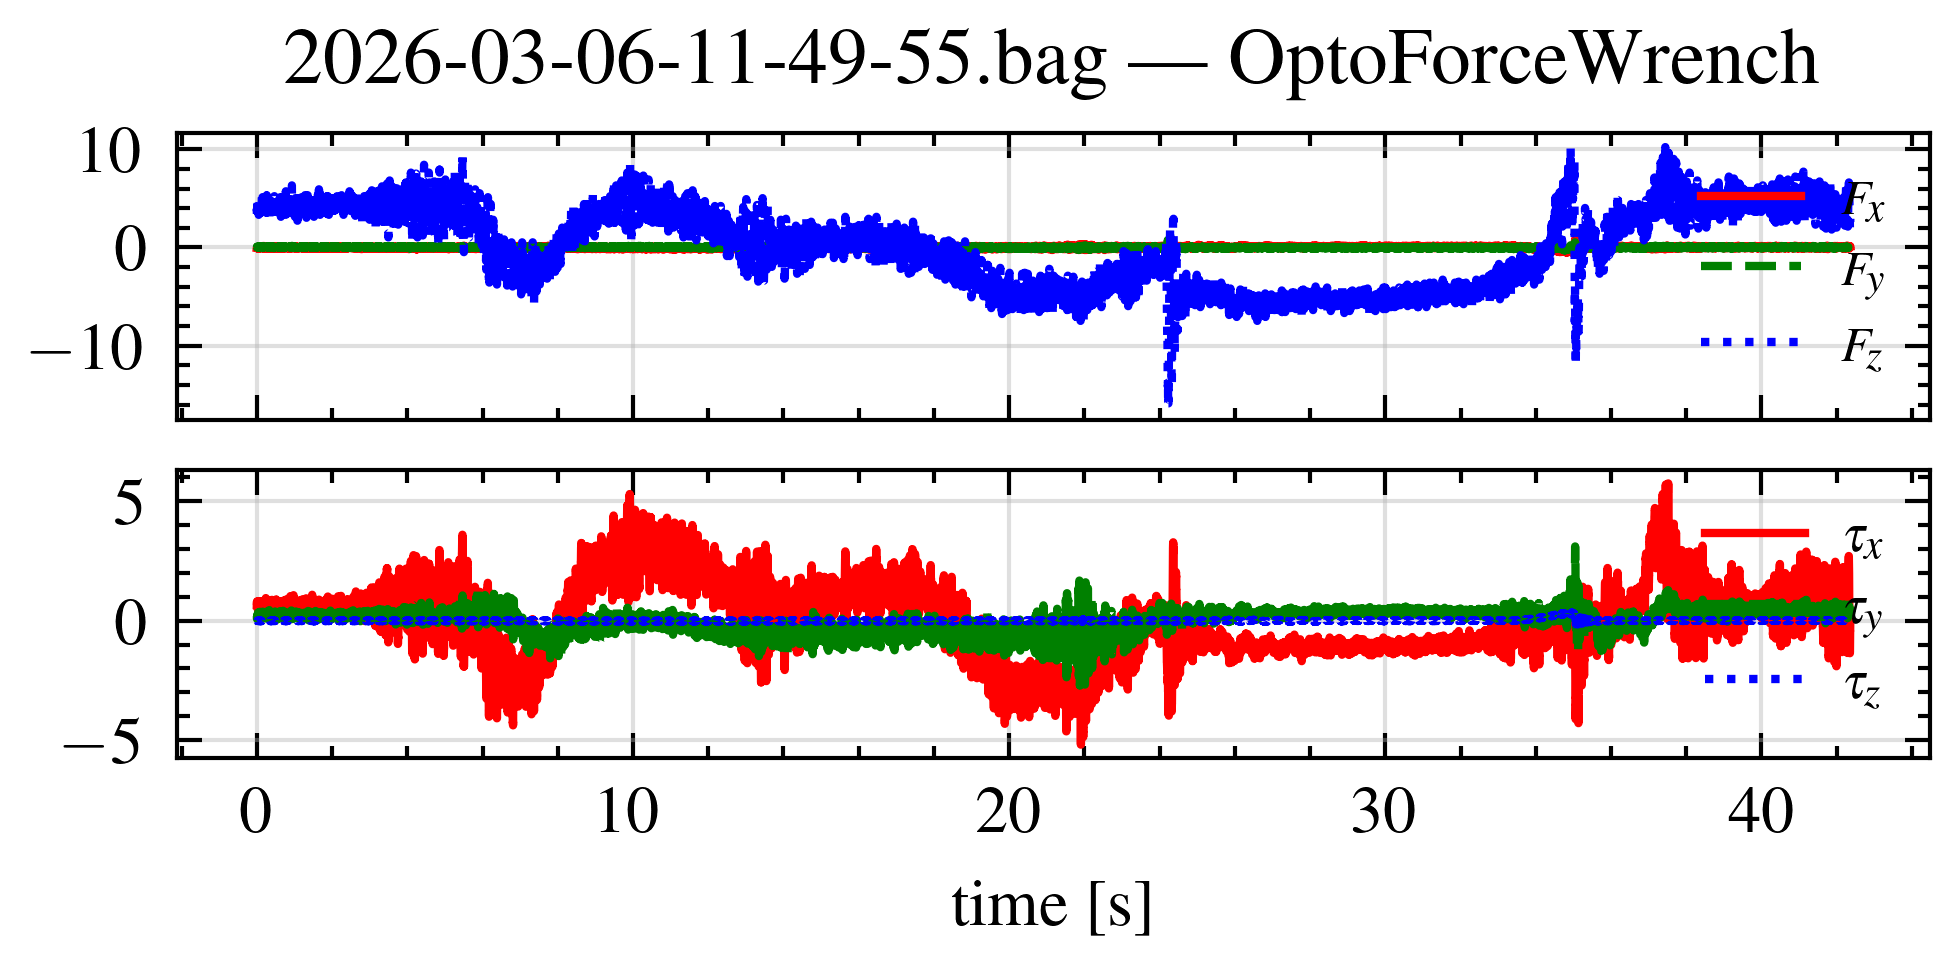

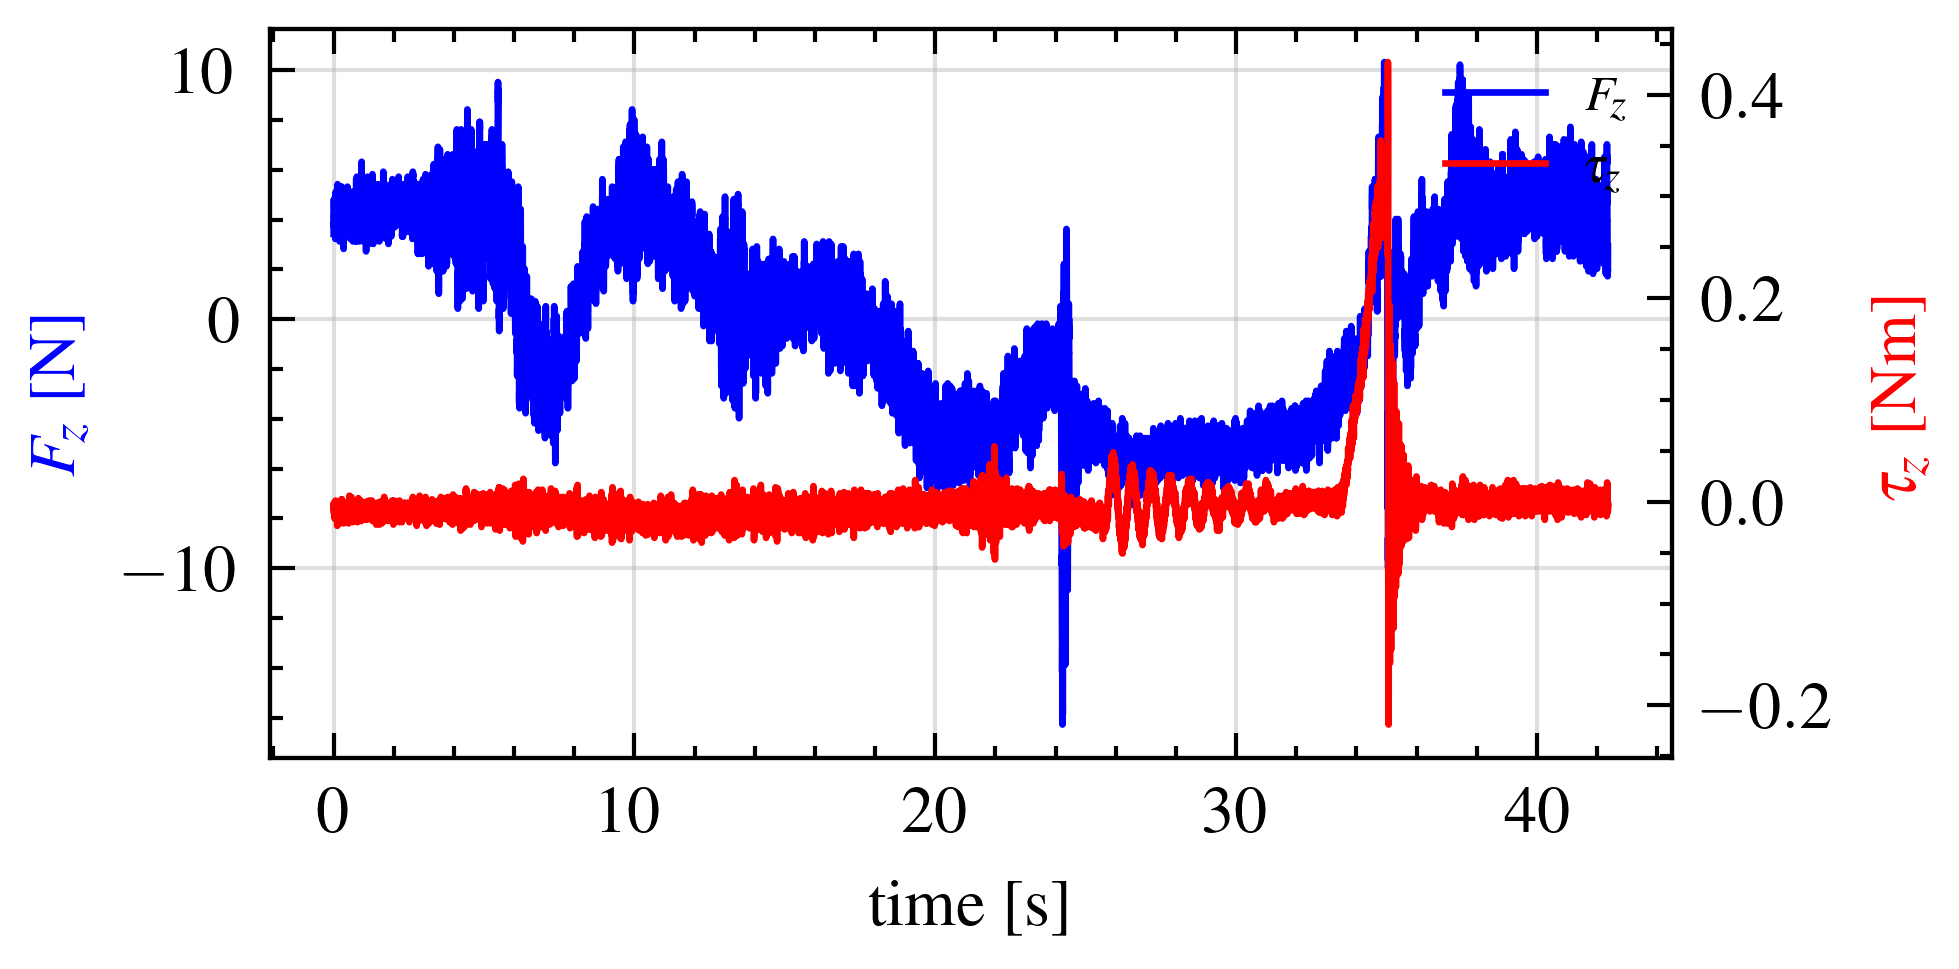

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench.pdf

=== processing 2026-03-06-11-50-50.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-50-50 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


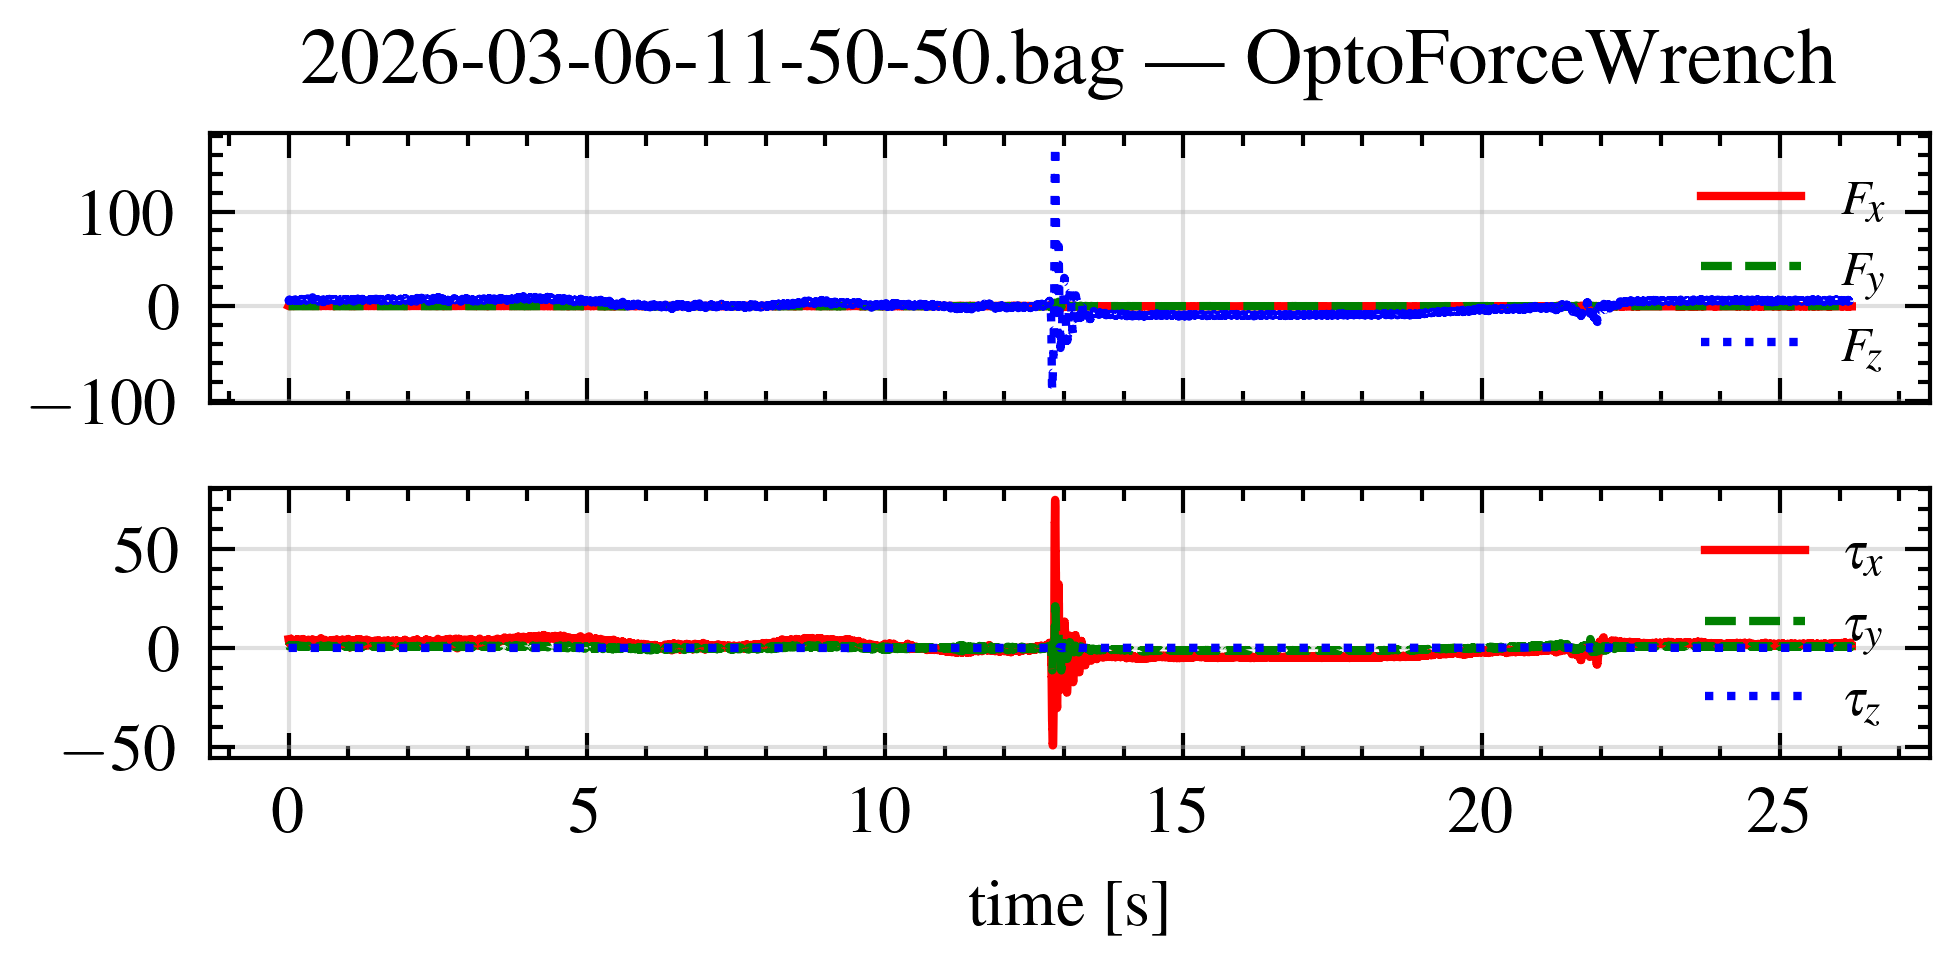

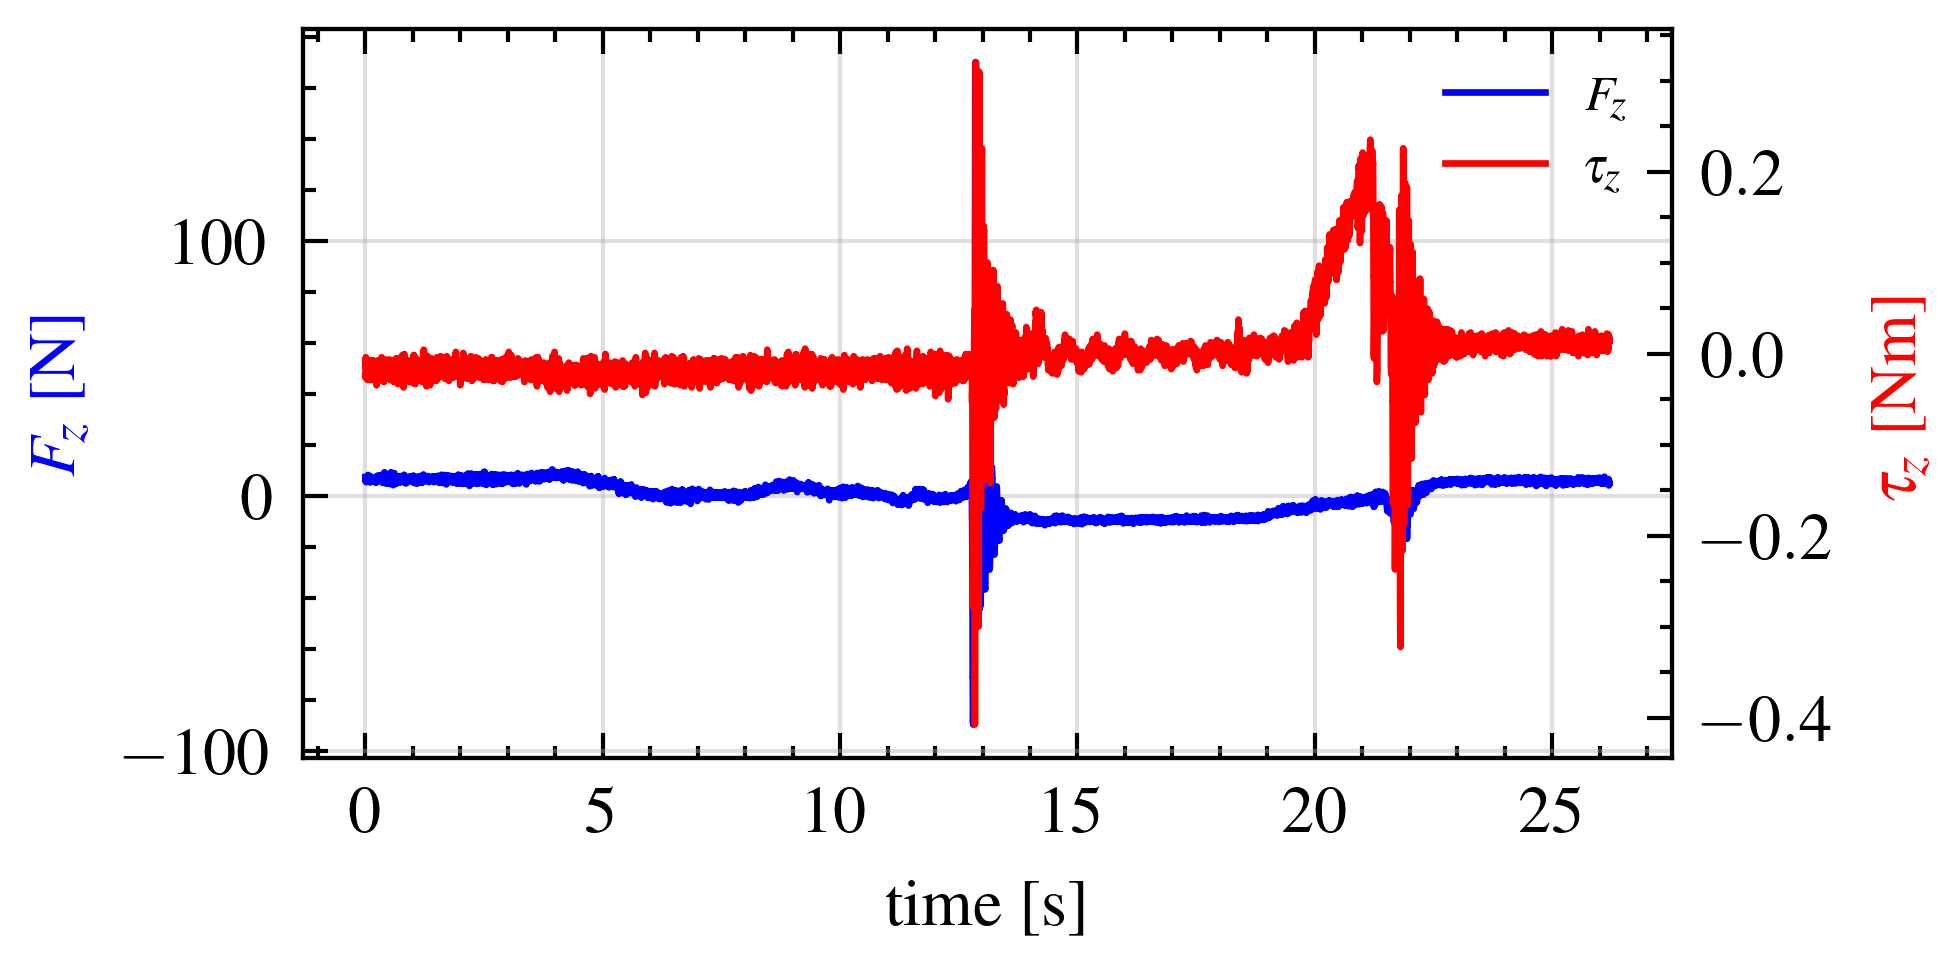

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-50-50.bag_OptoForceWrench.pdf

=== processing 2026-03-06-11-52-30.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-52-30 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


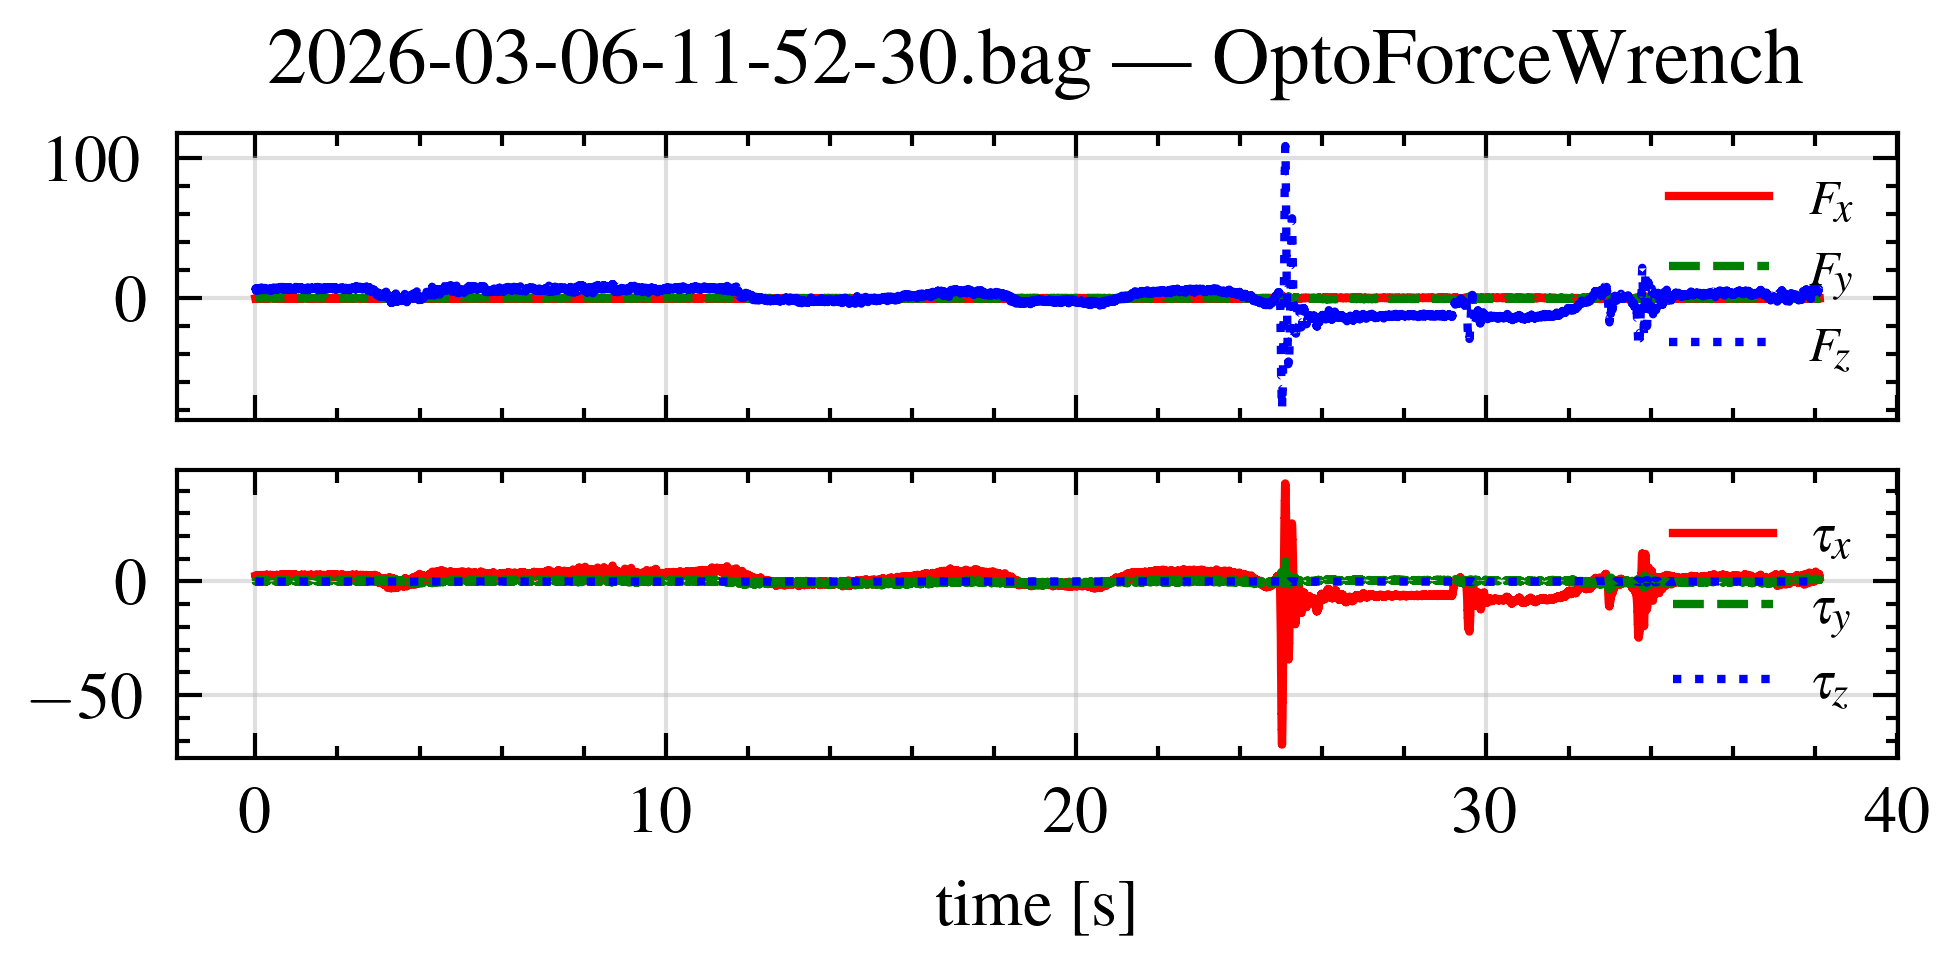

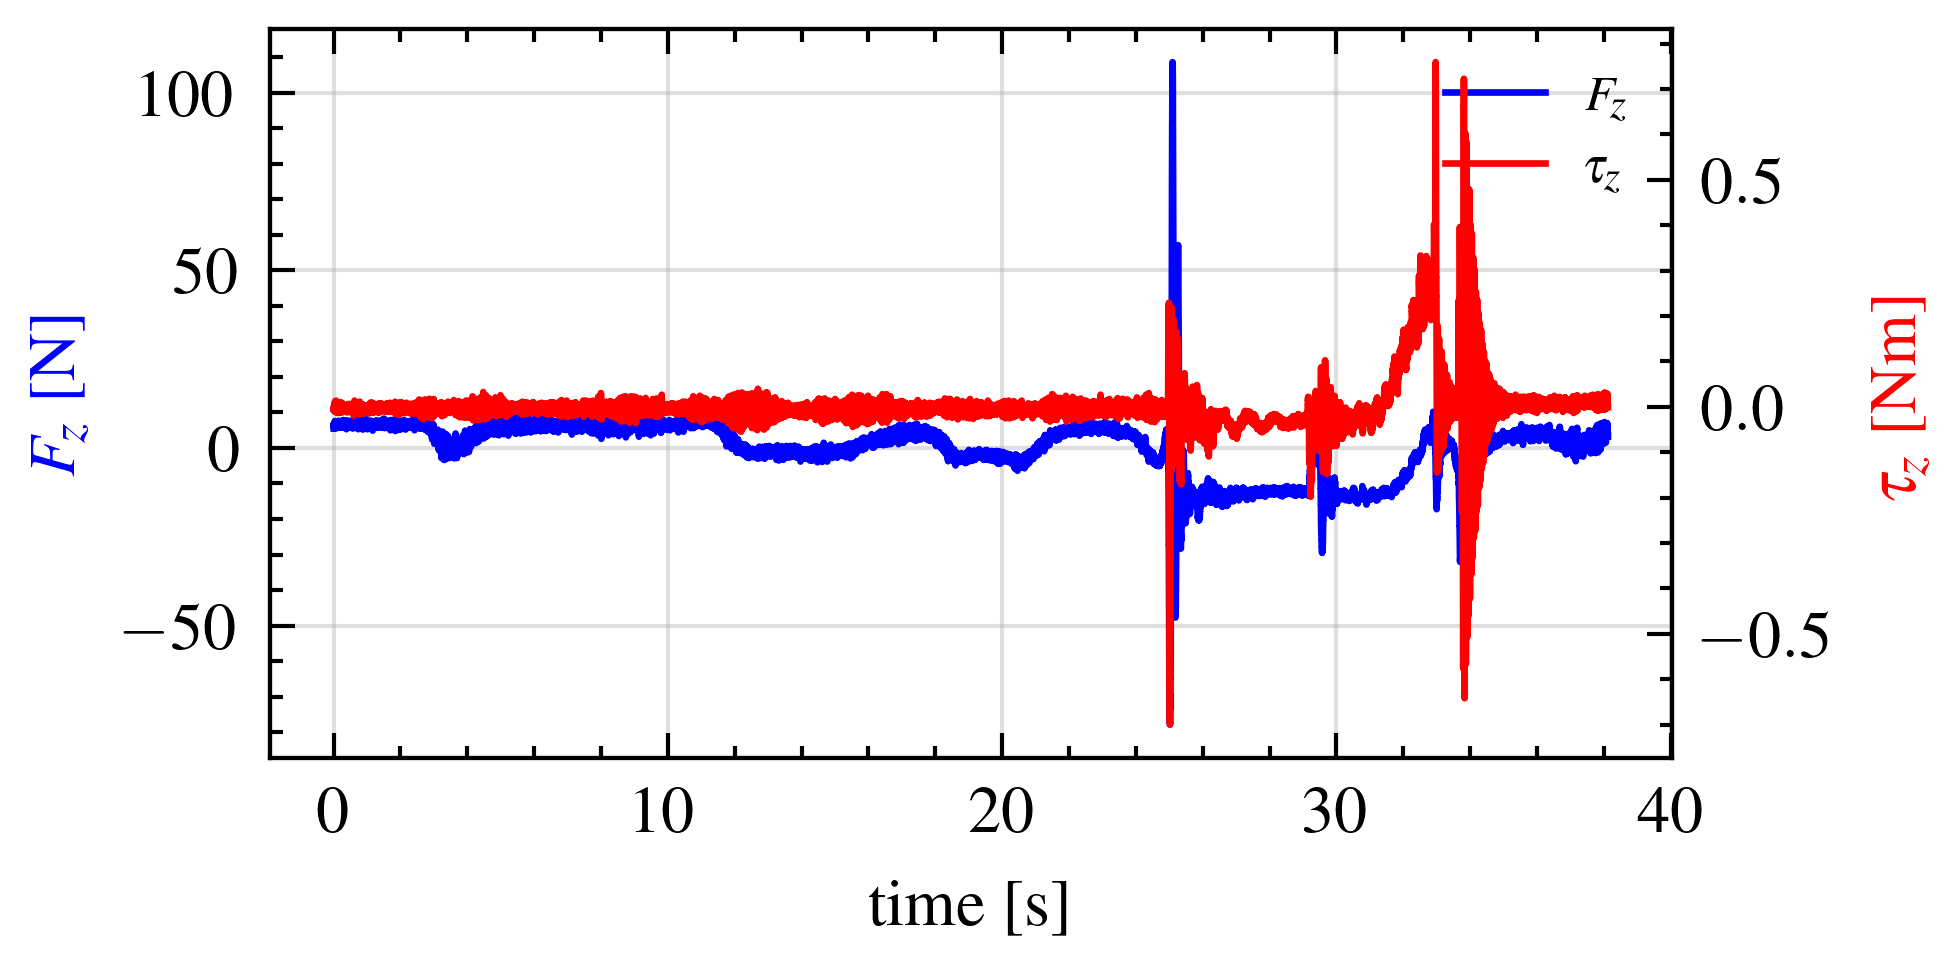

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-52-30.bag_OptoForceWrench.pdf

=== processing 2026-03-06-11-58-35.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-58-35 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


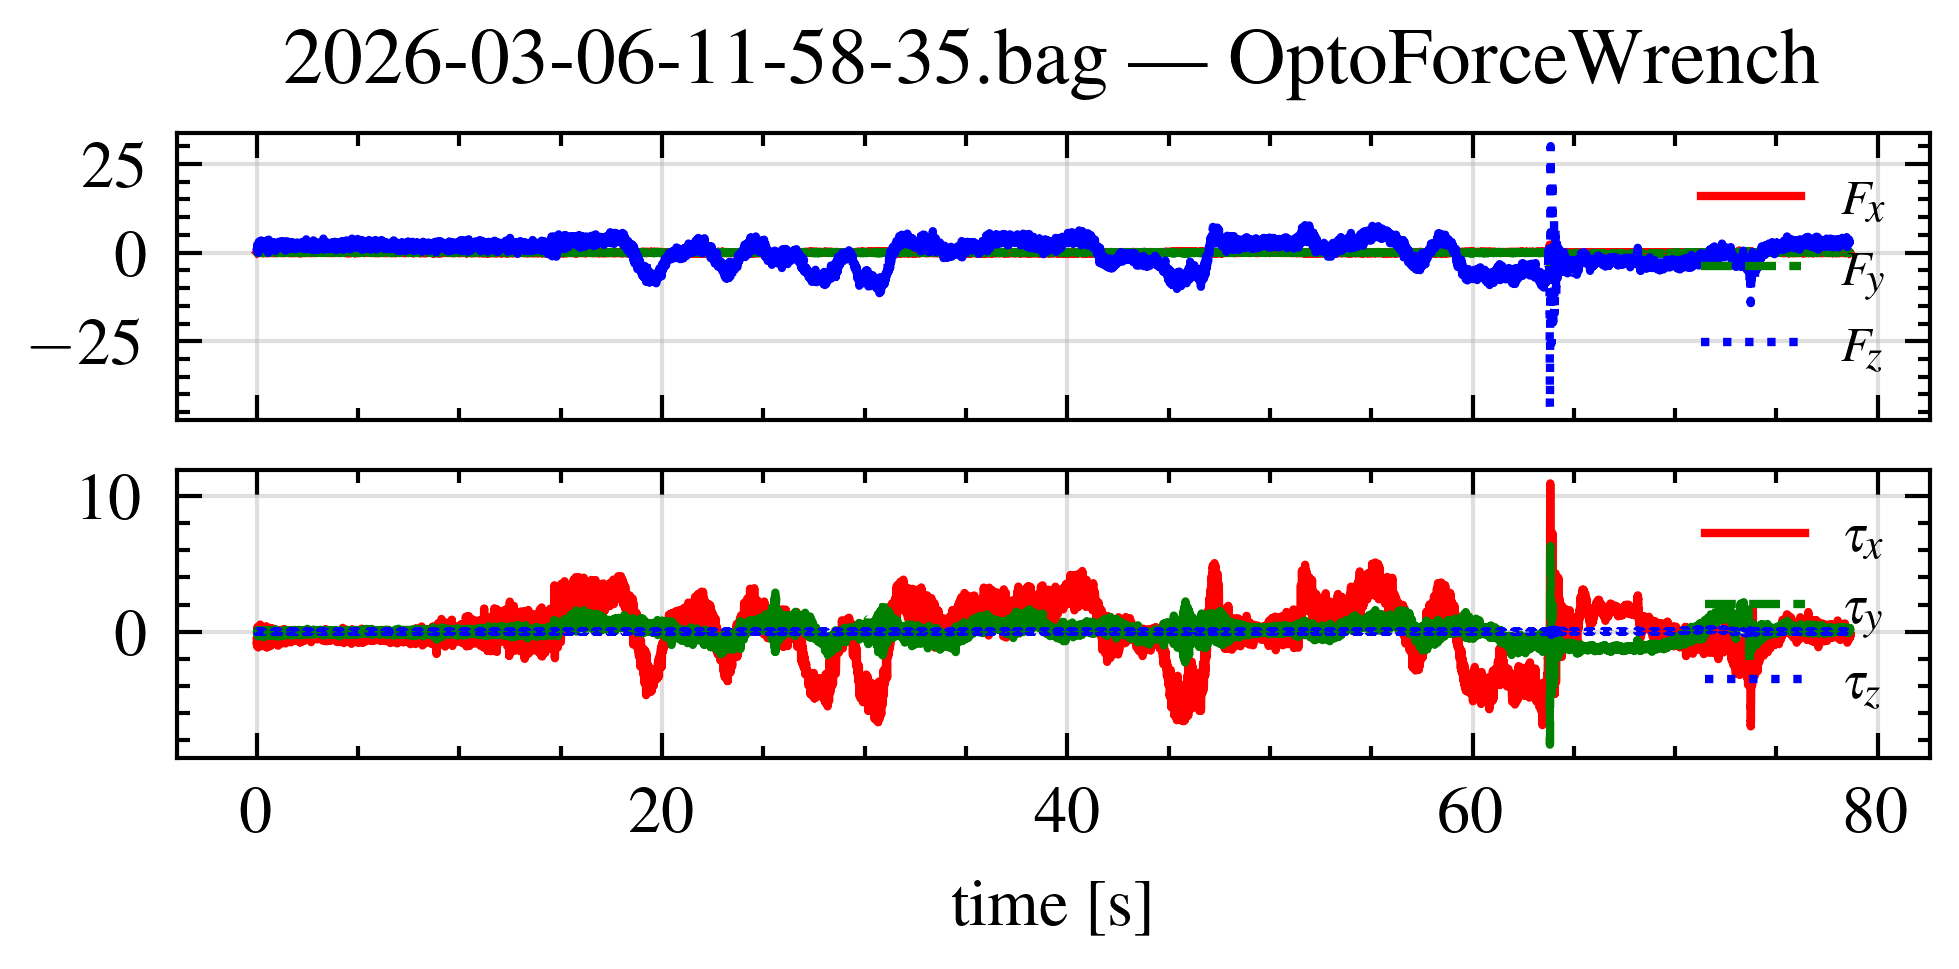

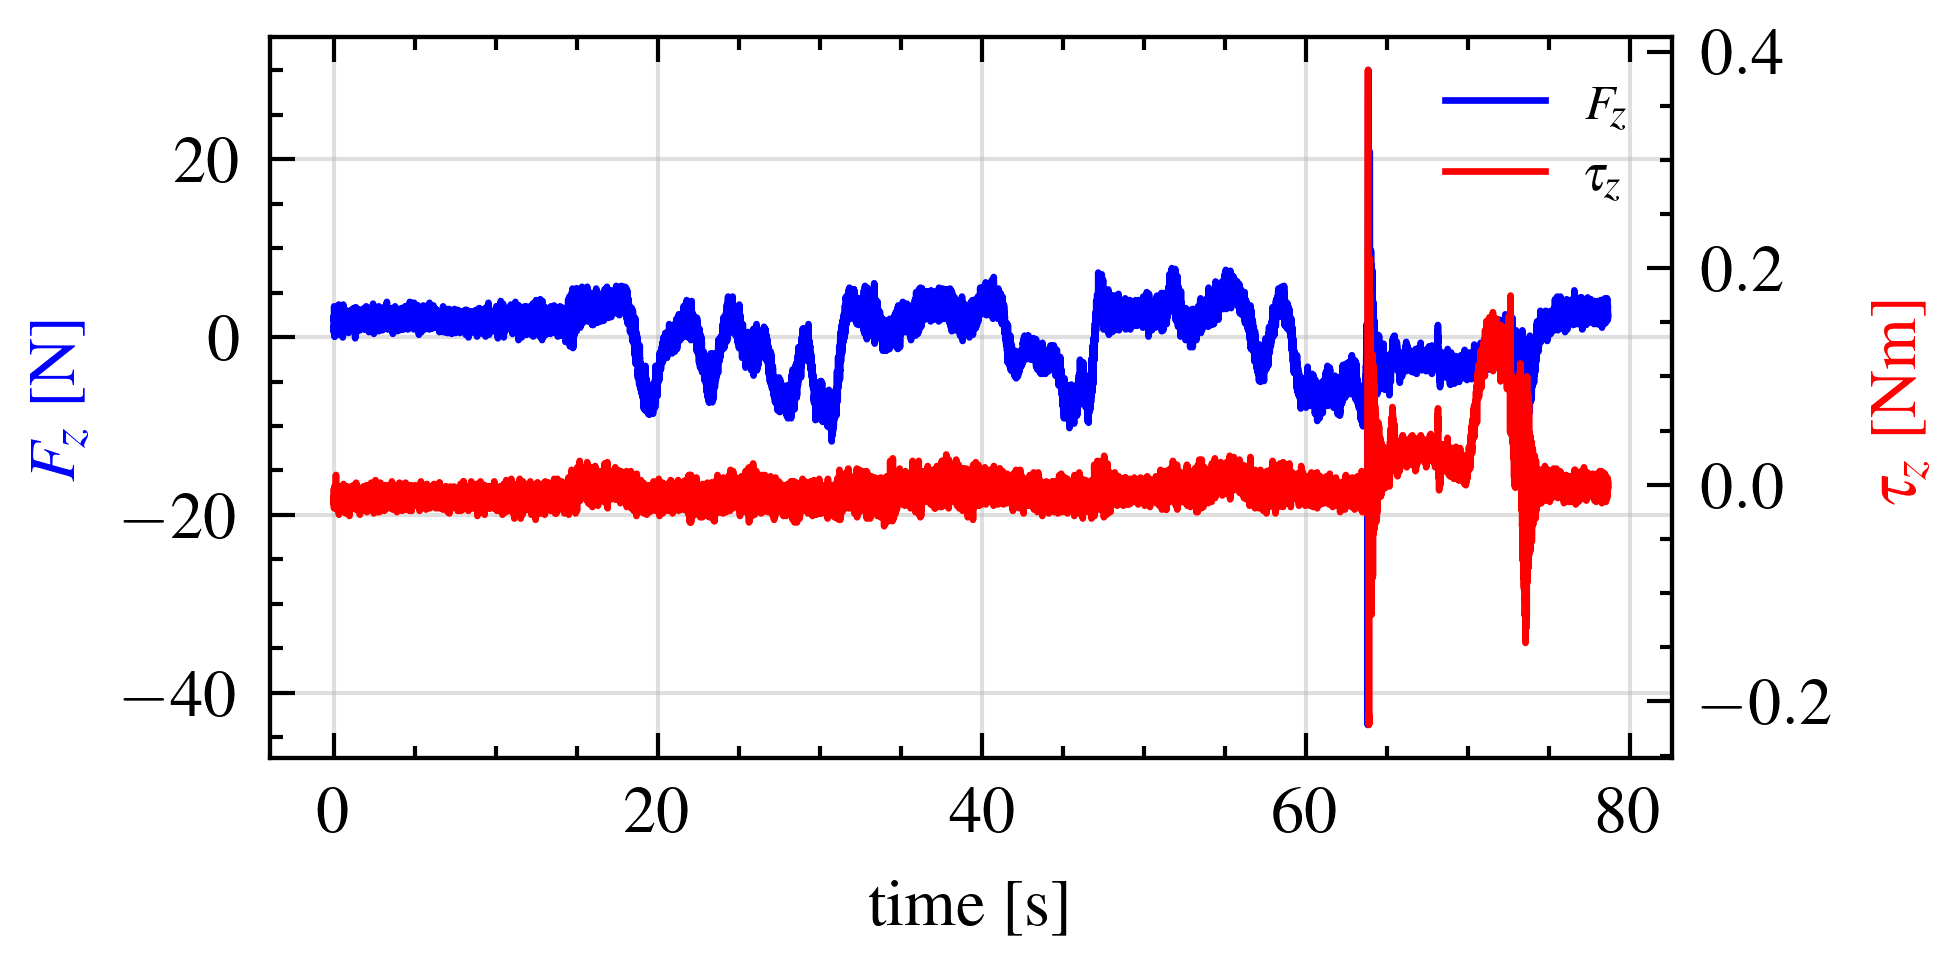

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-58-35.bag_OptoForceWrench.pdf

=== processing 2026-03-06-12-00-03.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-12-00-03 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


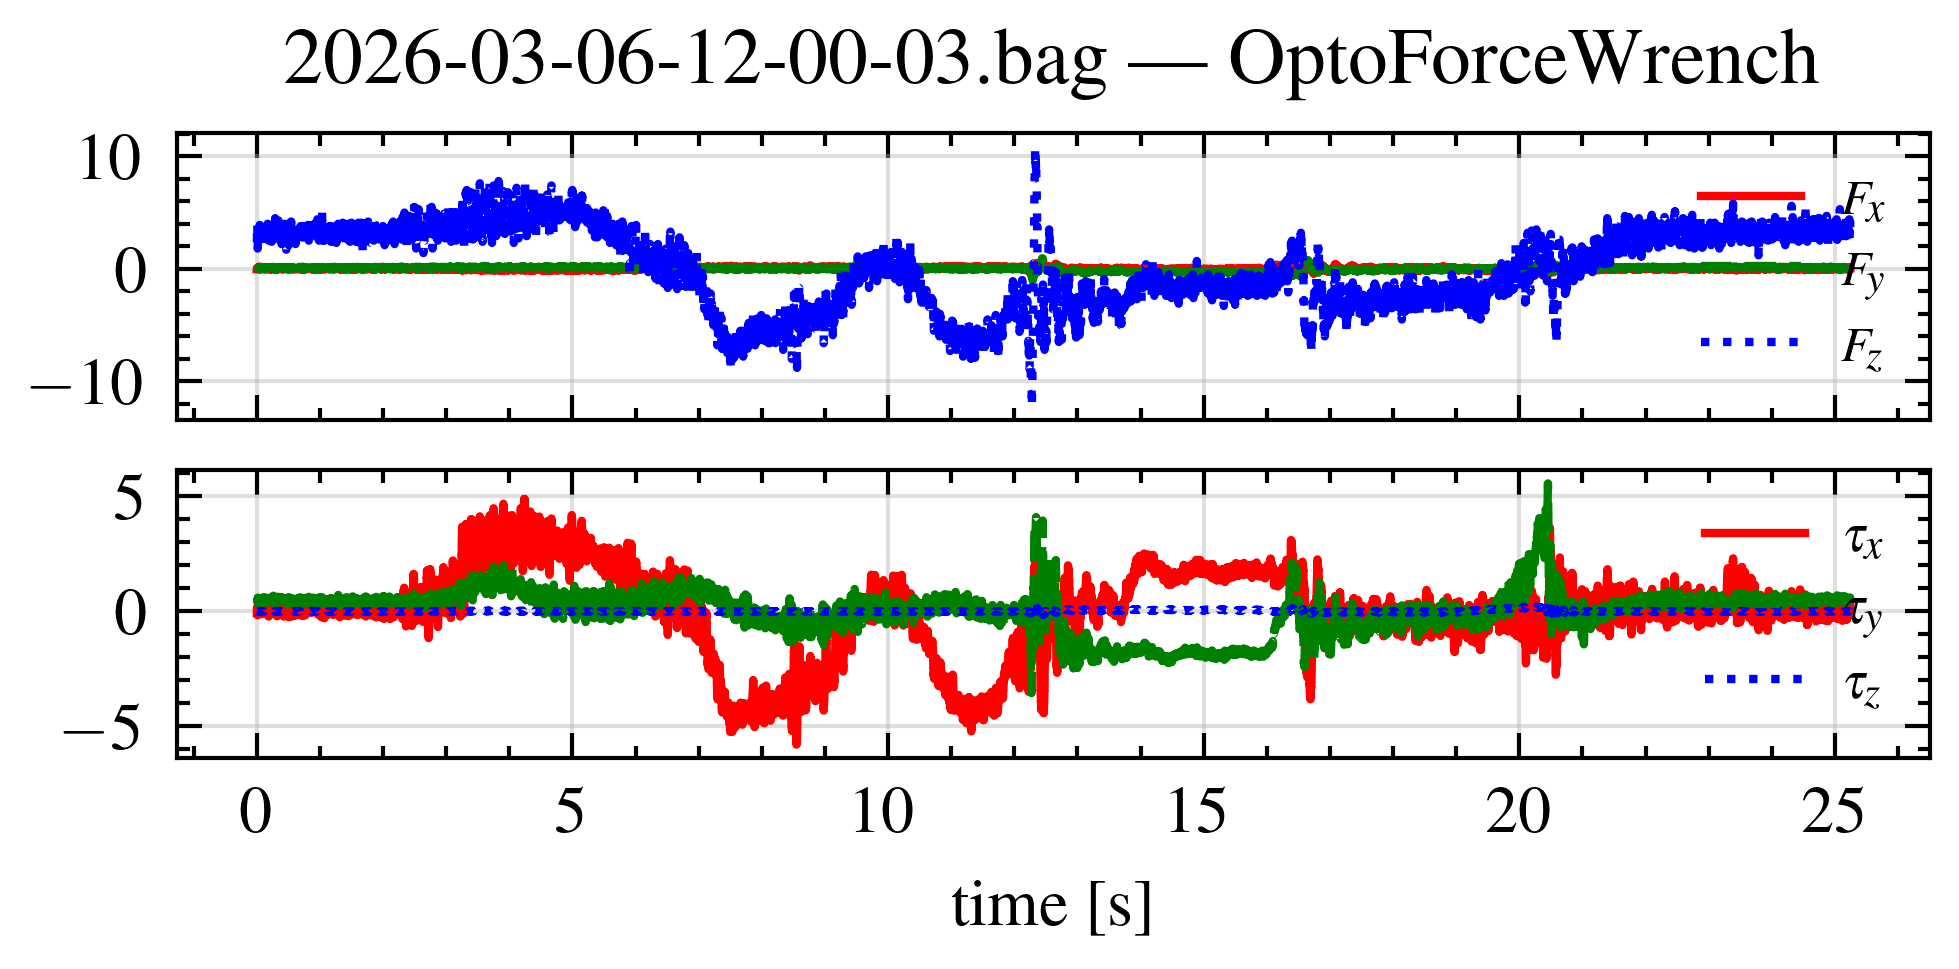

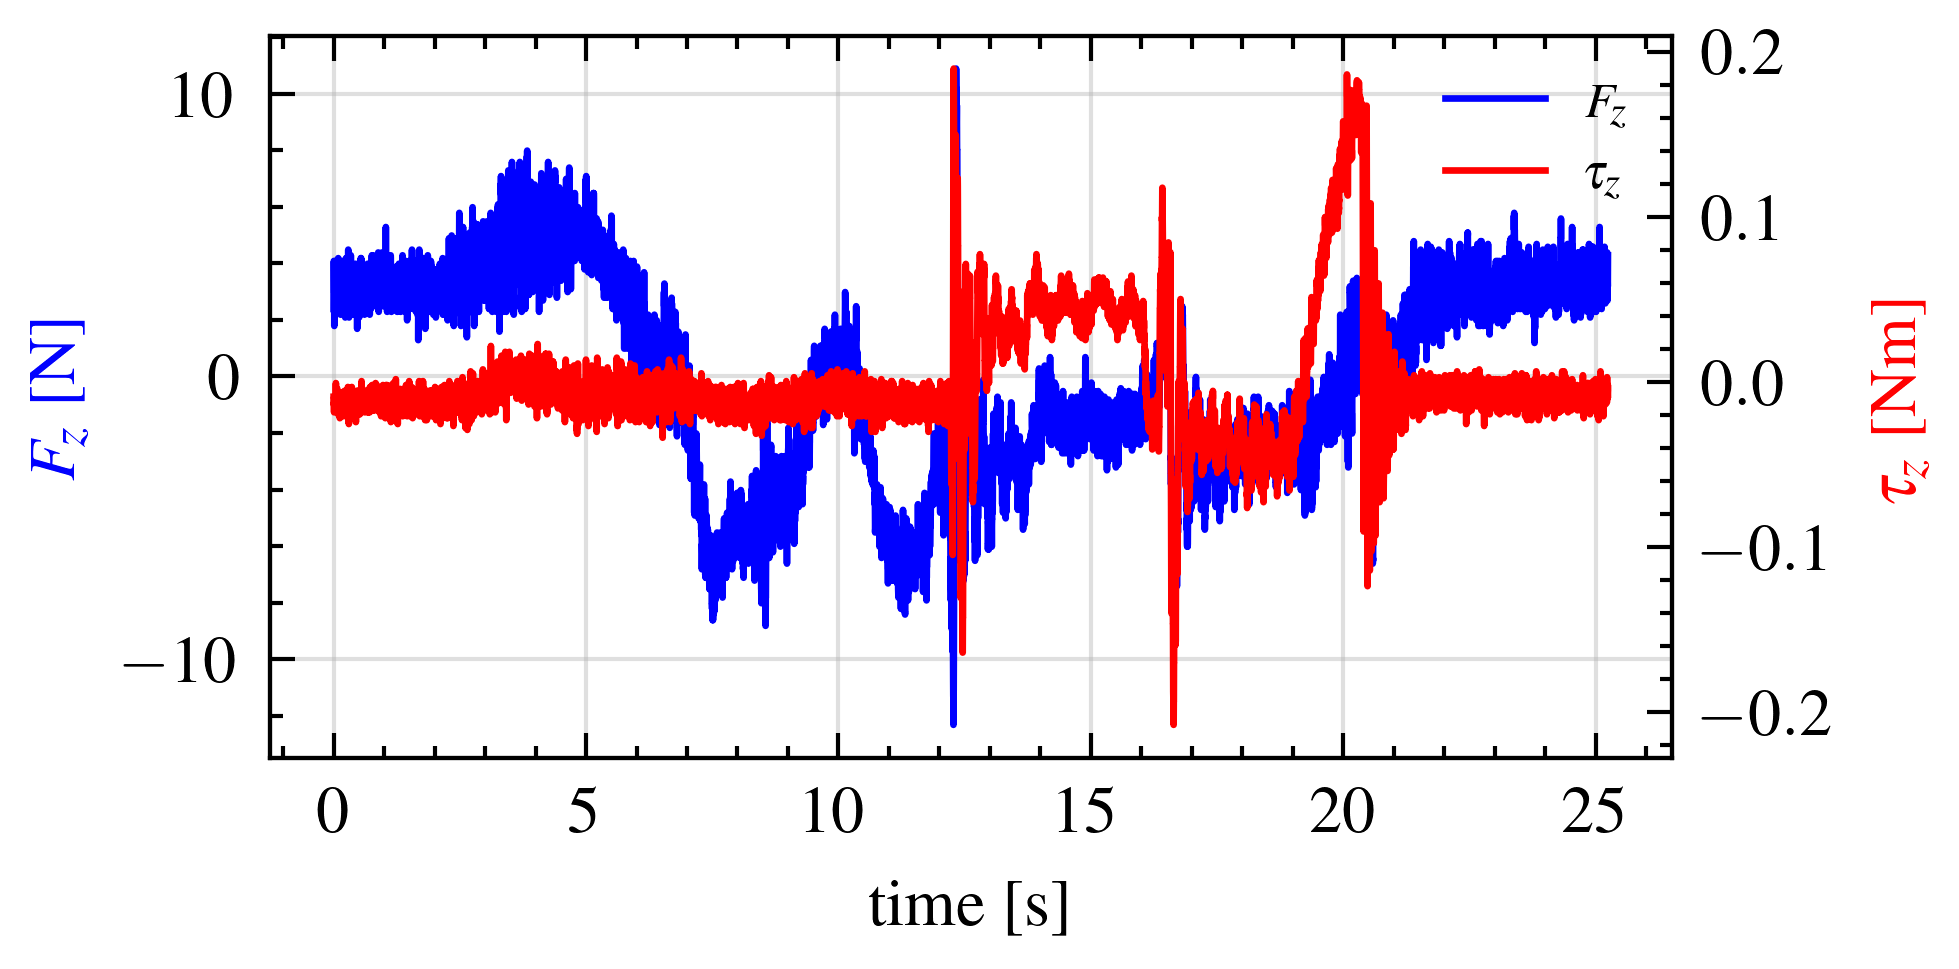

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-12-00-03.bag_OptoForceWrench.pdf


In [33]:
# iterate over bag files in uav_perching directory and plot wrench data
bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")
# IEEE column-sized figures
FIGSIZE_IN = (3.25, 1.6)
DPI = 600
def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()
    for topic in topics:
        # only look at optoforce wrench topics (raw/filtered)
        if any(x in topic for x in ["rosout", "raw", "filtered2"]):
            continue
        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)
        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue
        if df.empty:
            continue
        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        wrench_cols = [
            "wrench.force.x",
            "wrench.force.y",
            "wrench.force.z",
            "wrench.torque.x",
            "wrench.torque.y",
            "wrench.torque.z",
        ]

        for col in wrench_cols:
            if col in df.columns:
                df[col] = df[col] - df[col].mean()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_IN, constrained_layout=True, sharex=True)
        
        ax1.plot(df['time_s'], df['wrench.force.x'], label=r'$F_x$', color='r')
        ax1.plot(df['time_s'], df['wrench.force.y'], label=r'$F_y$', color='g')
        ax1.plot(df['time_s'], df['wrench.force.z'], label=r'$F_z$', color='b')
        
        ax1.set_title(f"{os.path.basename(bag_path)} | {os.path.basename(topic)}")
        ax2.plot(df['time_s'], df['wrench.torque.x'], label=r'$\tau_x$', color='r')
        ax2.plot(df['time_s'], df['wrench.torque.y'], label=r'$\tau_y$', color='g')
        ax2.plot(df['time_s'], df['wrench.torque.z'], label=r'$\tau_z$', color='b')
        ax2.set_xlabel("time [s]")
        ax1.grid(True, alpha=0.4)
        ax2.grid(True, alpha=0.4)
        ax1.legend(fontsize=6, loc="upper right")
        ax2.legend(fontsize=6, loc="upper right")
        
        fig, ax1 = plt.subplots(figsize=FIGSIZE_IN, constrained_layout=True)
        ax2 = ax1.twinx()

        ln1 = ax1.plot(df["time_s"], df["wrench.force.z"], label=r"$F_z$", color="b", linewidth=0.8)
        ln2 = ax2.plot(df["time_s"], df["wrench.torque.z"], label=r"$\tau_z$", color="r", linewidth=0.8)

        ax1.set_xlabel("time [s]")
        ax1.set_ylabel(r"$F_z$ [N]", color="b")
        ax2.set_ylabel(r"$\tau_z$ [Nm]", color="r")
        ax1.grid(True, alpha=0.4)

        lines = ln1 + ln2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, fontsize=6, loc="upper right")
        
        out = os.path.join(fig_dir, f"{os.path.basename(bag_path)}_{os.path.basename(topic).replace('/','_')}.pdf")
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"    saved {out}")
        
# loop through directory
for fname in sorted(os.listdir(bag_dir)):
    if not fname.endswith(".bag"):
        continue
    process_bag(os.path.join(bag_dir, fname))



=== processing 2026-03-06-11-49-55.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-49-55 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


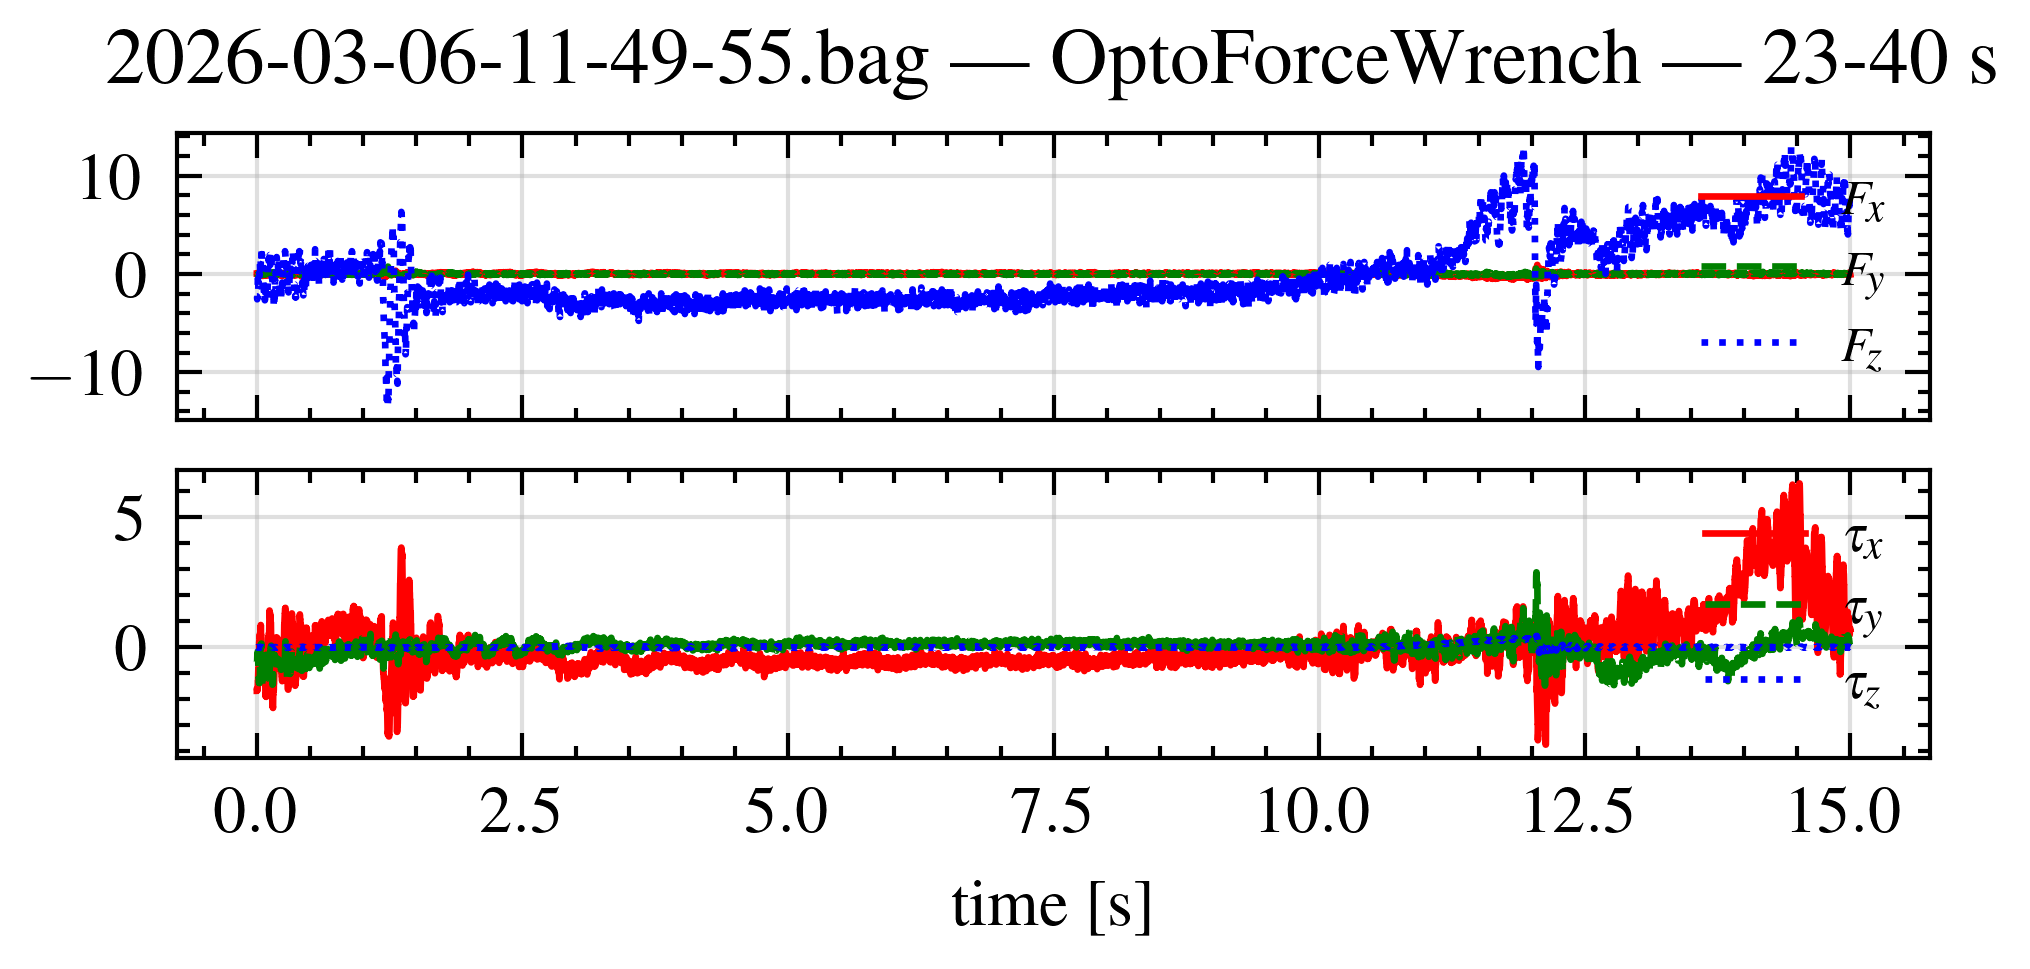

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench_23_40_all.pdf


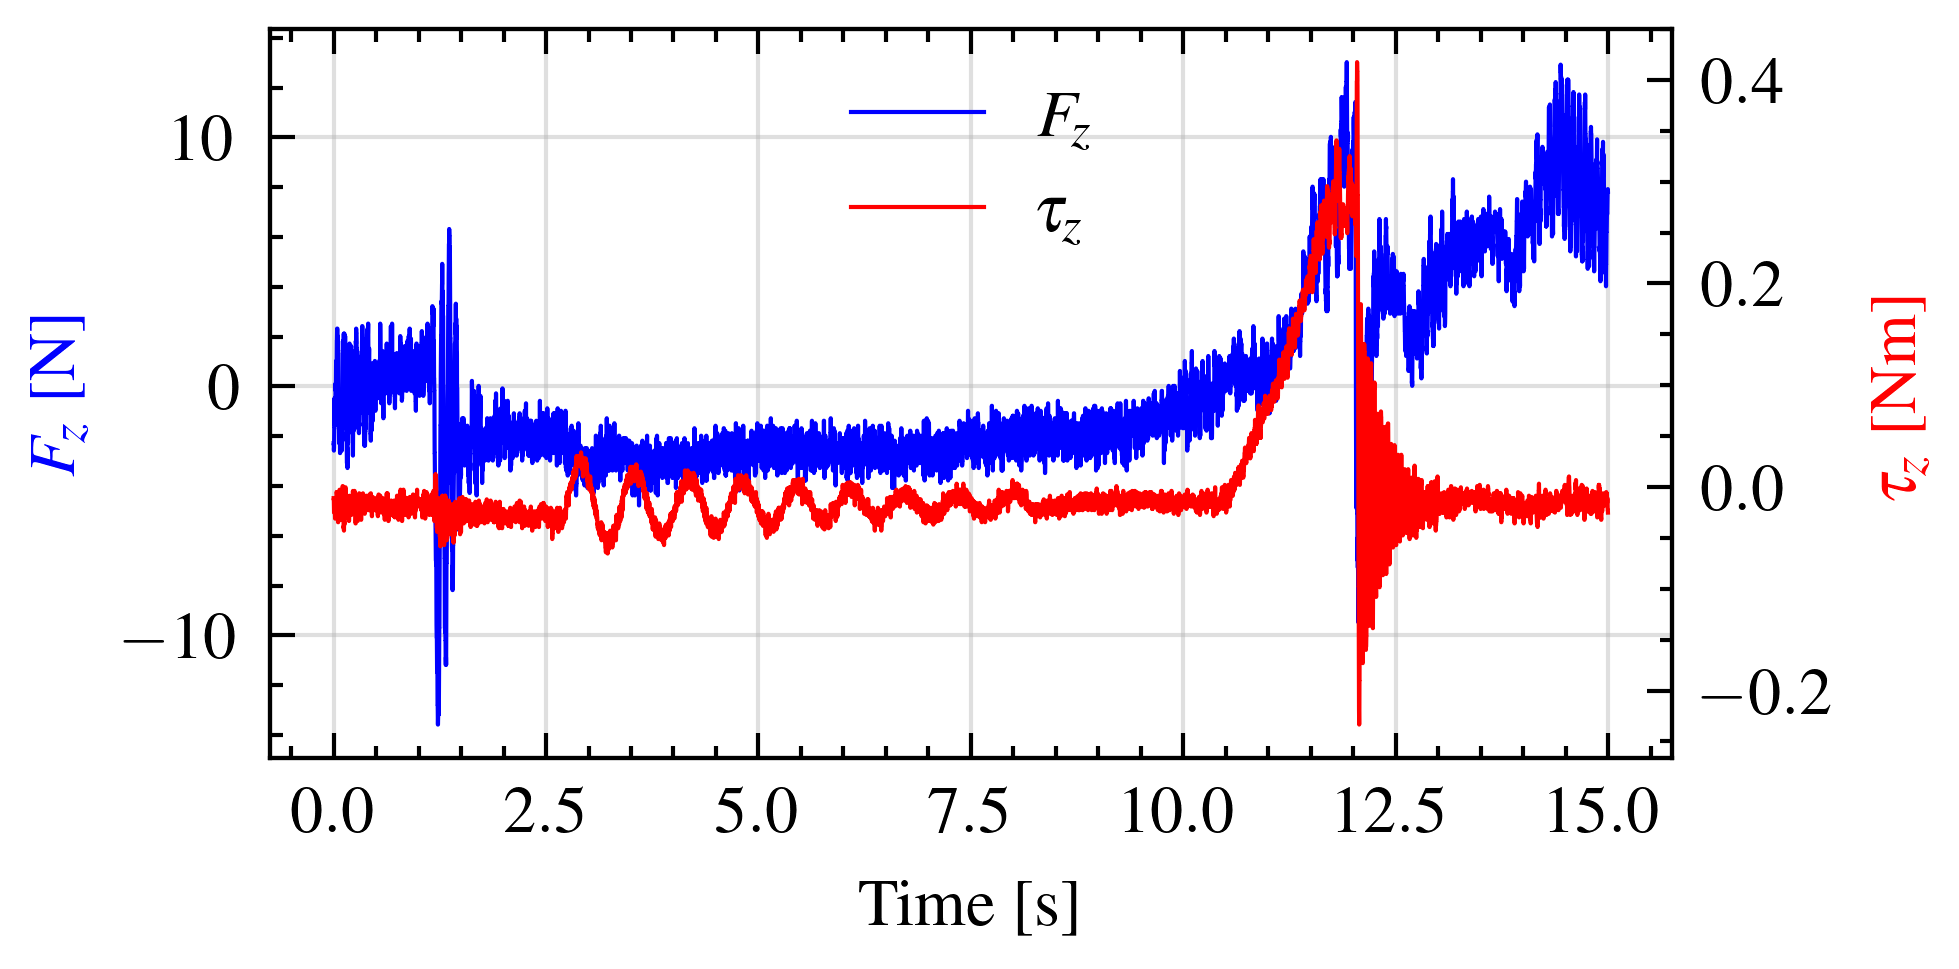

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/2026-03-06-11-49-55.bag_OptoForceWrench_23_40_fz_tauz.pdf


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from bagpy import bagreader

bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")
target_bag = "2026-03-06-11-49-55.bag"

FIGSIZE_IN = (3.25, 1.6)
DPI = 600

def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()

    for topic in topics:
        if any(x in topic for x in ["rosout", "raw", "filtered2"]):
            continue

        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)

        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue

        if df.empty or "Time" not in df.columns:
            continue

        # original time scaled to zero
        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        # keep only 23 to 40 s
        df = df[(df["time_s"] >= 23.0) & (df["time_s"] <=38.0)].copy()
        if df.empty:
            print("    no data in selected time window")
            continue

        # shift cropped timeline back to zero
        df["time_s"] = df["time_s"] - df["time_s"].iloc[0]

        # remove bias after cropping
        wrench_cols = [
            "wrench.force.x",
            "wrench.force.y",
            "wrench.force.z",
            "wrench.torque.x",
            "wrench.torque.y",
            "wrench.torque.z",
        ]
        for col in wrench_cols:
            if col in df.columns:
                df[col] = df[col] - df[col].mean()

        # figure 2
        fig2, ax_left = plt.subplots(figsize=FIGSIZE_IN, constrained_layout=True)
        ax_right = ax_left.twinx()

        ln1 = ax_left.plot(
            df["time_s"], df["wrench.force.z"],
            label=r"$F_z$", color="b", linewidth=0.5
        )
        ln2 = ax_right.plot(
            df["time_s"], df["wrench.torque.z"],
            label=r"$\tau_z$", color="r", linewidth=0.5
        )

        ax_left.set_xlabel("Time [s]")
        ax_left.set_ylabel(r"$F_z$ [N]", color="b")
        ax_right.set_ylabel(r"$\tau_z$ [Nm]", color="r")

        ax_left.tick_params(axis="y")
        ax_right.tick_params(axis="y")
        ax_left.grid(True, alpha=0.4)

        lines = ln1 + ln2
        labels = [l.get_label() for l in lines]
        ax_left.legend(lines, labels, fontsize=8, loc="upper center")

        out2 = os.path.join(
            fig_dir,
            f"{os.path.basename(bag_path)}_{os.path.basename(topic).replace('/','_')}_23_40_fz_tauz.pdf"
        )
        fig2.savefig(out2, dpi=DPI, bbox_inches="tight")
        plt.show()
        plt.close(fig2)
        print(f"    saved {out2}")

# process only the selected bag
bag_path = os.path.join(bag_dir, target_bag)
if os.path.exists(bag_path):
    process_bag(bag_path)
else:
    print(f"bag not found: {bag_path}")


=== processing 2026-03-06-11-49-55.bag ===
[INFO]  Data folder /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/../bags/uav_perching/2026-03-06-11-49-55 already exists. Not creating.
  topic: /optoforce_node/OptoForceWrench


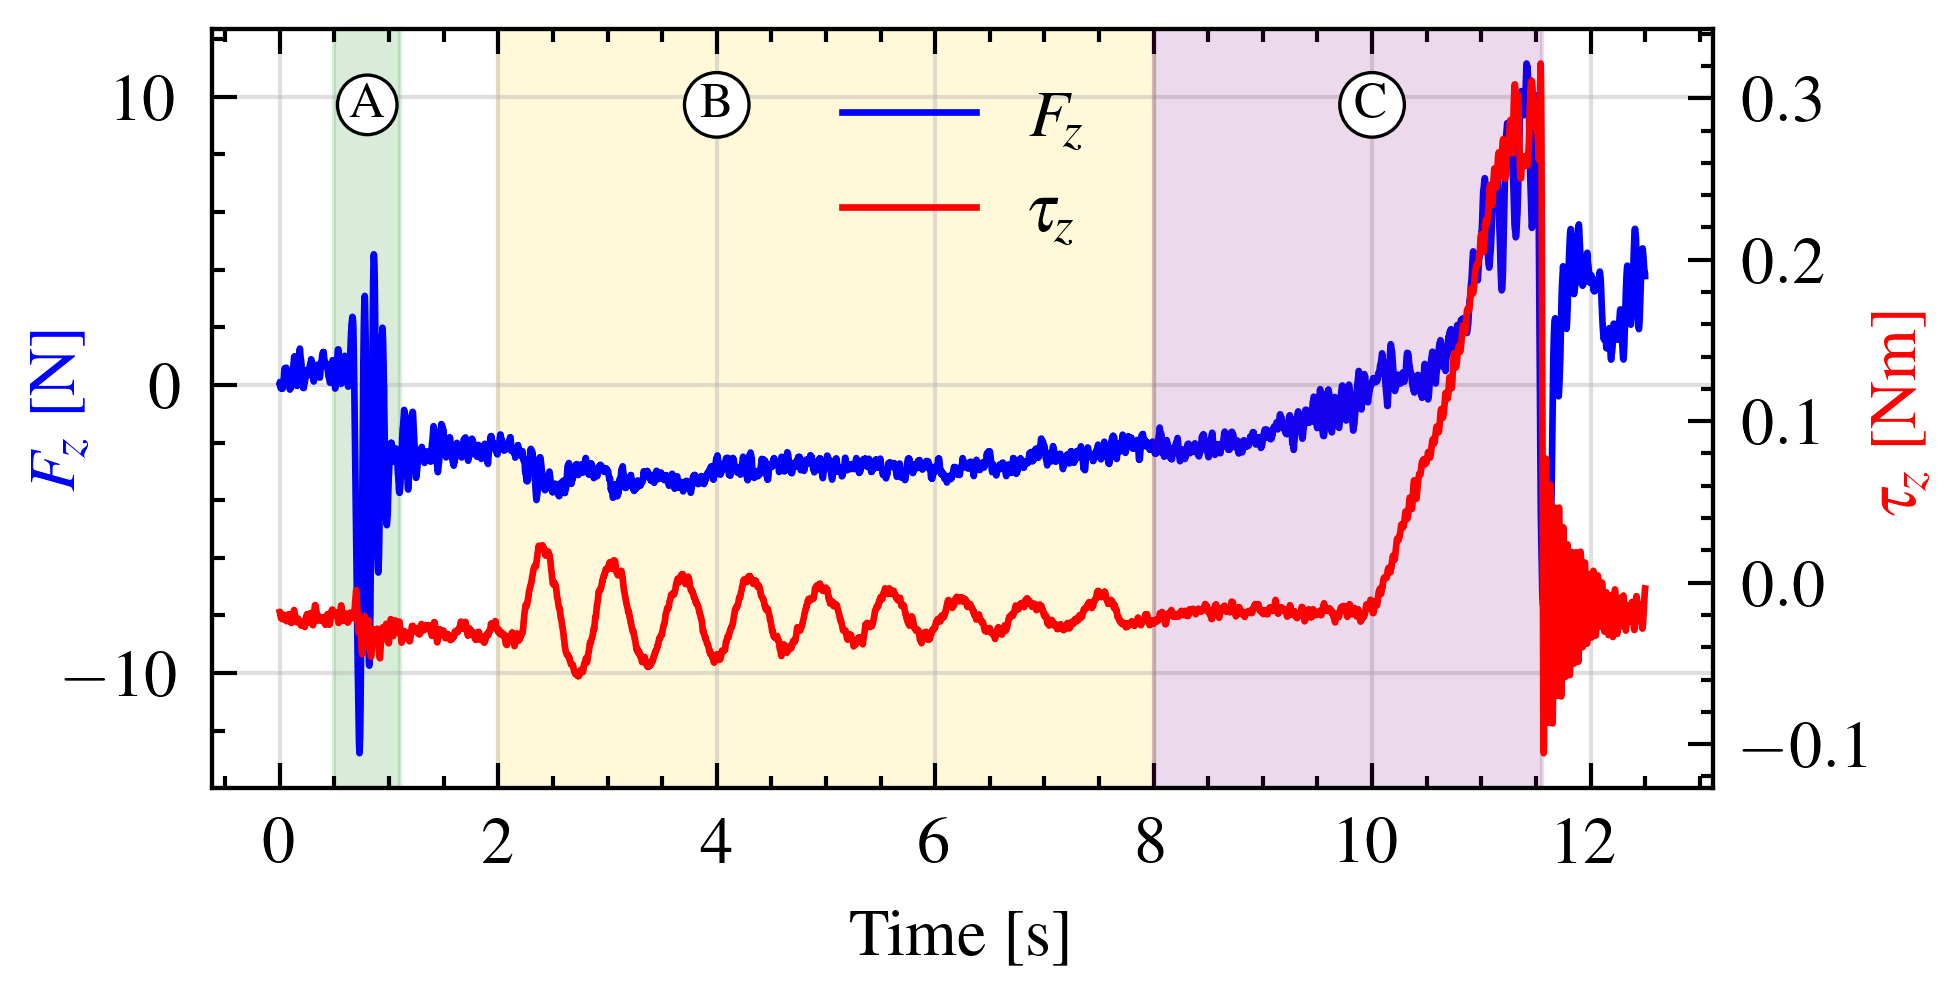

    saved /home/jakob/SOBER_A_Soft_Base_Passive_Gripper_for_Surface_Attachment/visualization/figures_uav_perching/attach_and_release.pdf


In [144]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from bagpy import bagreader

bag_dir = os.path.join(os.getcwd(), "..", "bags", "uav_perching")
target_bag = "2026-03-06-11-49-55.bag"

FIGSIZE_IN = (3.25, 1.65)
DPI = 600

def smooth_signal(series, window=55):
    return series.rolling(window=window, center=True, min_periods=1).mean()

def process_bag(bag_path: str):
    print(f"\n=== processing {os.path.basename(bag_path)} ===")
    b = bagreader(bag_path)
    topics = b.topic_table["Topics"].tolist()

    for topic in topics:
        if any(x in topic for x in ["rosout", "raw", "filtered2"]):
            continue

        print(f"  topic: {topic}")
        csvfile = b.message_by_topic(topic)

        try:
            df = pd.read_csv(csvfile)
        except Exception as e:
            print("    failed to read csv", e)
            continue

        if df.empty or "Time" not in df.columns:
            continue

        t0 = df["Time"].iloc[0]
        df["time_s"] = df["Time"] - t0

        df = df[(df["time_s"] >= 23.5) & (df["time_s"] <= 36)].copy()
        if df.empty:
            print("    no data in selected time window")
            continue

        df["time_s"] = df["time_s"] - df["time_s"].iloc[0]

        wrench_cols = [
            "wrench.force.x",
            "wrench.force.y",
            "wrench.force.z",
            "wrench.torque.x",
            "wrench.torque.y",
            "wrench.torque.z",
        ]
        for col in wrench_cols:
            if col in df.columns:
                df[col] = df[col] - df[col].mean()
        
        df["wrench.force.z"] = df["wrench.force.z"] - df["wrench.force.z"].iloc[5]

        # smooth only for plotting
        df["wrench.force.z_smooth"] = smooth_signal(df["wrench.force.z"], window=25)
        df["wrench.torque.z_smooth"] = smooth_signal(df["wrench.torque.z"], window=25)

        fig2, ax_left = plt.subplots(figsize=FIGSIZE_IN, constrained_layout=True)
        ax_right = ax_left.twinx()

        ln1 = ax_left.plot(
            df["time_s"], df["wrench.force.z_smooth"],
            label=r"$F_z$", color="b", linewidth=0.8
        )
        ln2 = ax_right.plot(
            df["time_s"], df["wrench.torque.z_smooth"],
            label=r"$\tau_z$", color="r", linewidth=0.8
        )

        ax_left.set_xlabel("Time [s]")
        ax_left.set_ylabel(r"$F_z$ [N]", color="b", labelpad=-3)
        ax_right.set_ylabel(r"$\tau_z$ [Nm]", color="r", labelpad=-1)

        ax_left.grid(True, alpha=0.4)

        lines = ln1 + ln2
        labels = [l.get_label() for l in lines]
        ax_left.legend(lines, labels, fontsize=8, loc="upper center")

        ax_left.axvspan(0.5, 1.1, color="green", alpha=0.15, zorder=0, linewidth=0.5)
        ax_left.axvspan(2.0, 8.0, color="gold", alpha=0.15, zorder=0, linewidth=0.5)
        ax_left.axvspan(8.0, 11.56, color="purple", alpha=0.15, zorder=2, linewidth=0.5)
        
        ax_left.text(
            0.8, 0.90, "A",
            transform=ax_left.get_xaxis_transform(),
            ha="center", va="center", fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.15", facecolor="white", edgecolor="black", linewidth=0.4)
        )

        ax_left.text(
            4.0, 0.90, "B",
            transform=ax_left.get_xaxis_transform(),
            ha="center", va="center", fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.4)
        )

        ax_left.text(
            10, 0.90, "C",
            transform=ax_left.get_xaxis_transform(),
            ha="center", va="center", fontsize=6, fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.4)
        )
        
        out2 = os.path.join(
            fig_dir,
            f"attach_and_release.pdf"
        )
        fig2.savefig(out2, dpi=DPI, bbox_inches="tight", pad_inches=0.0)
        plt.show()
        plt.close(fig2)
        print(f"    saved {out2}")

bag_path = os.path.join(bag_dir, target_bag)
if os.path.exists(bag_path):
    process_bag(bag_path)
else:
    print(f"bag not found: {bag_path}")